In [1]:
from utils.sae.sae_base import SAEBase
sae_cfg = {
    "device": 'cuda:1',
    "normalize_acts": True,
    "top_k": 50,
    "layer": 30,
    "name": "Llama-Scope",
    "dtype": "bfloat16"
}
sae_path = "/mindopt/project/source/sae/Llama/Llama-3.1-8B/Llama-Scope/Llama3_1-8B-Base-L30R-8x/checkpoints/final.safetensors"
sae_base = SAEBase(sae_path, **sae_cfg)

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import trange

# 提取 W_dec 向量
W_dec = sae_base.sae['W_dec']  # 假设 W_dec 是一个 (n_latent, d_model) 的张量

# 计算余弦相似度矩阵
n_latent = W_dec.shape[0]
cos_sim_values = []

# 计算所有向量两两之间的余弦相似度
for i in trange(n_latent):
    for j in range(i + 1, n_latent):
        cos_sim = F.cosine_similarity(W_dec[i].unsqueeze(0), W_dec[j].unsqueeze(0))  # 计算余弦相似度
        cos_sim_values.append(cos_sim.item())  # 将结果添加到列表中

# 绘制余弦相似度分布的直方图
plt.figure(figsize=(8, 6))
plt.hist(cos_sim_values, bins=50, edgecolor='black')
plt.title("Cosine Similarity Distribution of W_dec")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()

  0%|          | 28/32768 [01:25<27:37:06,  3.04s/it]


KeyboardInterrupt: 

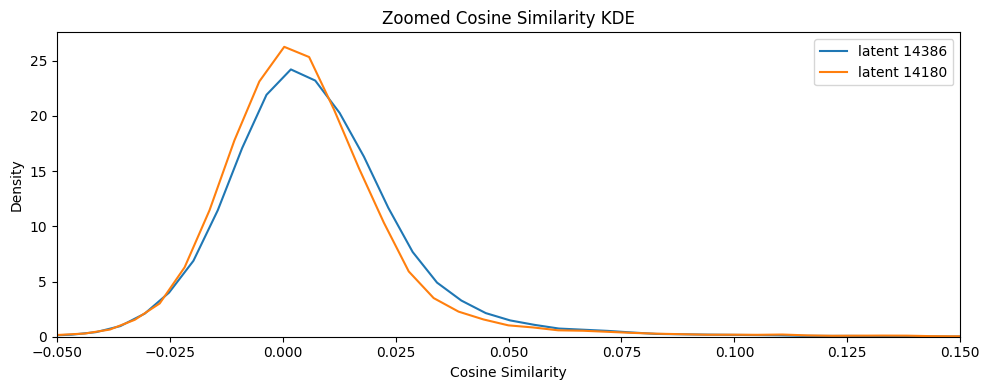

401
token: Account, latent: 13733,[14386]CosSim: -0.0138, [14180]CosSim: 0.0086
token: APPLE, latent: 12042,[14386]CosSim: -0.0066, [14180]CosSim: -0.0139
token: alis, latent: 9898,[14386]CosSim: 0.0198, [14180]CosSim: 0.0171
token:  assisted, latent: 510,[14386]CosSim: 0.0024, [14180]CosSim: 0.0152
token: anan, latent: 7361,[14386]CosSim: 0.0033, [14180]CosSim: -0.0076
token: alloc, latent: 9898,[14386]CosSim: 0.0198, [14180]CosSim: 0.0171
token: ANNEL, latent: 7361,[14386]CosSim: 0.0033, [14180]CosSim: -0.0076
token:  apolog, latent: 9684,[14386]CosSim: 0.1108, [14180]CosSim: -0.0050
token:  Alb, latent: 9898,[14386]CosSim: 0.0198, [14180]CosSim: 0.0171
token:  All, latent: 1850,[14386]CosSim: 0.0371, [14180]CosSim: 0.0164
token:  asks, latent: 8174,[14386]CosSim: 0.0211, [14180]CosSim: -0.0030
token:  attempted, latent: 8800,[14386]CosSim: -0.0063, [14180]CosSim: 0.0247
token:  ankle, latent: 7361,[14386]CosSim: 0.0033, [14180]CosSim: -0.0076
token: assemble, latent: 510,[14386]CosS

In [21]:
def cosine_sim_to_all(W, latent_idx):
    target = W[latent_idx]               # [d_model]
    cos_sim = torch.matmul(W, target)    # [n_latents]
    return cos_sim.detach().cpu()

parquet_path = (
    "/mindopt/project/SAEBench/sae_bench/artifacts/"
    "absorption/feature_absorption/custom_standard_0/"
    "layer_30_custom_standard_0.parquet"
)

letter = 'a'
letter_latent = [
    14386,
    14180
]

W = sae_base.sae['W_dec'].clone()
W = F.normalize(W, dim=1)   # cosine = dot
W = W.float()     

import seaborn as sns
plt.figure(figsize=(10, 4))
for idx in letter_latent:
    cos_sim = cosine_sim_to_all(W, idx)
    sns.kdeplot(cos_sim, label=f"latent {idx}", bw_adjust=0.8)
plt.xlim(-0.05, 0.15)   # 👈 核心
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("Zoomed Cosine Similarity KDE")
plt.legend()
plt.tight_layout()
plt.show()

import pandas as pd
df = pd.read_parquet(parquet_path)

absorption_latent = []

filtered_df = df[(df['letter'] == 'a') & (df['is_full_absorption'] == True)]

print(len(filtered_df))

for i in range(len(filtered_df)):
    print(f"token: {filtered_df.iloc[i]['token']}, "
        f"latent: {filtered_df.iloc[i]['top_projection_feat']},"
        f"[{letter_latent[0]}]CosSim: {F.cosine_similarity(W_dec[letter_latent[0]].unsqueeze(0), W_dec[filtered_df.iloc[i]['top_projection_feat']].unsqueeze(0)).item():.4f}, "
        f"[{letter_latent[1]}]CosSim: {F.cosine_similarity(W_dec[letter_latent[1]].unsqueeze(0), W_dec[filtered_df.iloc[i]['top_projection_feat']].unsqueeze(0)).item():.4f}"
    )


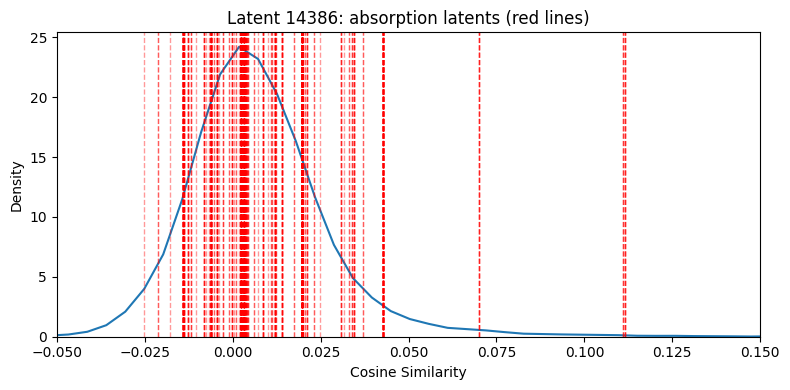

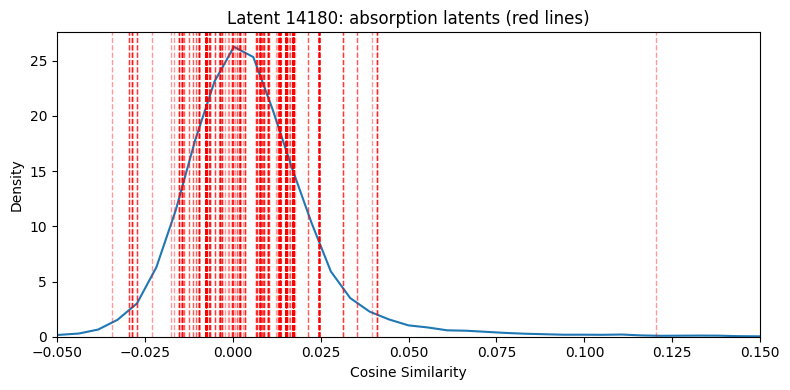

In [20]:
import numpy as np

# 所有 absorption latent 的 index
abs_latents = filtered_df['top_projection_feat'].values

# 对每个 letter latent，算 absorption 的 cos sim
abs_cos_sim = {}

for k in letter_latent:
    # 用已经 normalize + float 的 W
    cos_all = cosine_sim_to_all(W, k)  # [n_latents]
    abs_cos_sim[k] = cos_all[abs_latents].numpy()

import matplotlib.pyplot as plt
import seaborn as sns

for k in letter_latent:
    plt.figure(figsize=(8, 4))

    # 전체 KDE
    cos_sim = cosine_sim_to_all(W, k).numpy()
    sns.kdeplot(
        cos_sim,
        bw_adjust=0.8,
        label="all latents"
    )

    # absorption latent 竖线
    for v in abs_cos_sim[k]:
        plt.axvline(
            v,
            color="red",
            linestyle="--",
            alpha=0.4,
            linewidth=1
        )

    plt.xlim(-0.05, 0.15)
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.title(f"Latent {k}: absorption latents (red lines)")
    plt.tight_layout()
    plt.show()
